# Replikasi Eksperimen Giudici et al. (2020)
## *Network Models to Improve Automated Cryptocurrency Portfolio Management*

Notebook ini mengimplementasikan dan membandingkan strategi portofolio berikut:
1. **Equally Weighted (EW)** — Portofolio naif (1/N)
2. **Classical Markowitz (CM)** — Optimasi Mean-Variance tradisional
3. **Glasso Markowitz (GM)** — Markowitz dengan regularisasi Graphical Lasso
4. **Network Markowitz (NW)** — Integrasi RMT dan MST dengan penalti sentralitas
5. **Graph Diversification** — Diversifikasi berbasis Maximum Independent Set (MIS)

---
## Sel 1 — Persiapan Library

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Sel 2 — Memuat Data

Memuat data return dan harga dari file Excel. Fokus utama adalah pada dataset return harian untuk 10 aset kripto utama dalam periode 14 September 2017 hingga 17 Oktober 2019.

In [98]:
# Load data
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")
df_returns.head()

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


,BTC,ETH,XRP,USDT,BCH,LTC,BNB,EOS,XLM,TRX
Date,,,,,,,,,,
2017-09-15,0.142330,0.0,0.0,0.0,0.0,0.147883,0.0,0.0,0.0,0.0
2017-09-16,-0.003437,0.0,0.0,0.0,0.0,0.000947,0.0,0.0,0.0,0.0
2017-09-17,-0.011698,0.0,0.0,0.0,0.0,0.004794,0.0,0.0,0.0,0.0
2017-09-18,0.126296,0.0,0.0,0.0,0.0,0.135479,0.0,0.0,0.0,0.0
2017-09-19,-0.035104,0.0,0.0,0.0,0.0,-0.049661,0.0,0.0,0.0,0.0


---
## Sel 3 — Statistik Ringkasan (TABLE 1)

Menghasilkan tabel statistik deskriptif untuk setiap aset kripto: Mean, Standar Deviasi, Kurtosis, dan Skewness.

In [99]:
# Create summary statistics table
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


---
## Sel 4 — Visualisasi Harga Ternormalisasi (Figure 1 & 2)

Mereplikasi *Normalized cryptocurrency price series* dengan mengatur harga awal setiap aset menjadi 100 pada tanggal 7 Januari 2018.

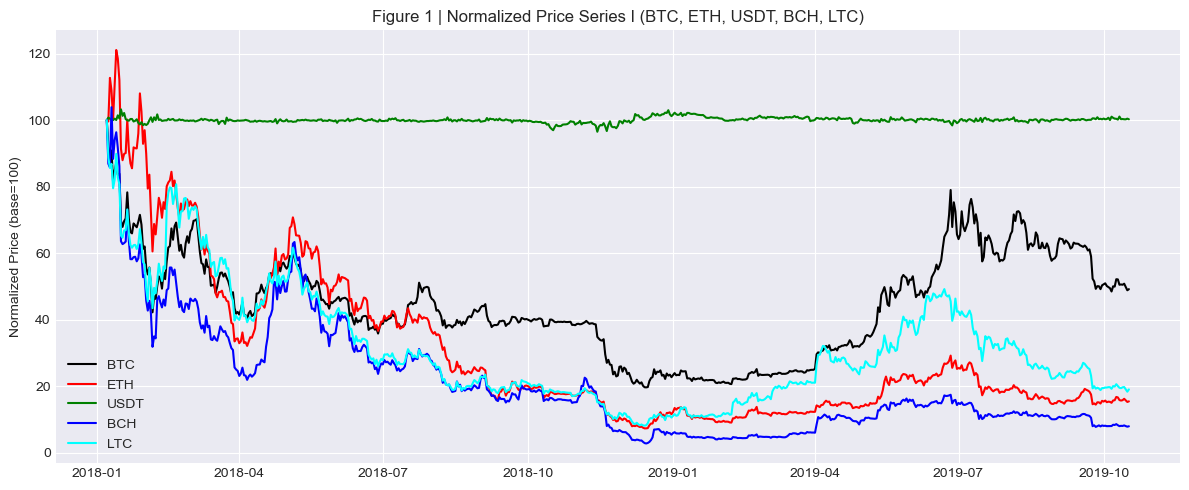

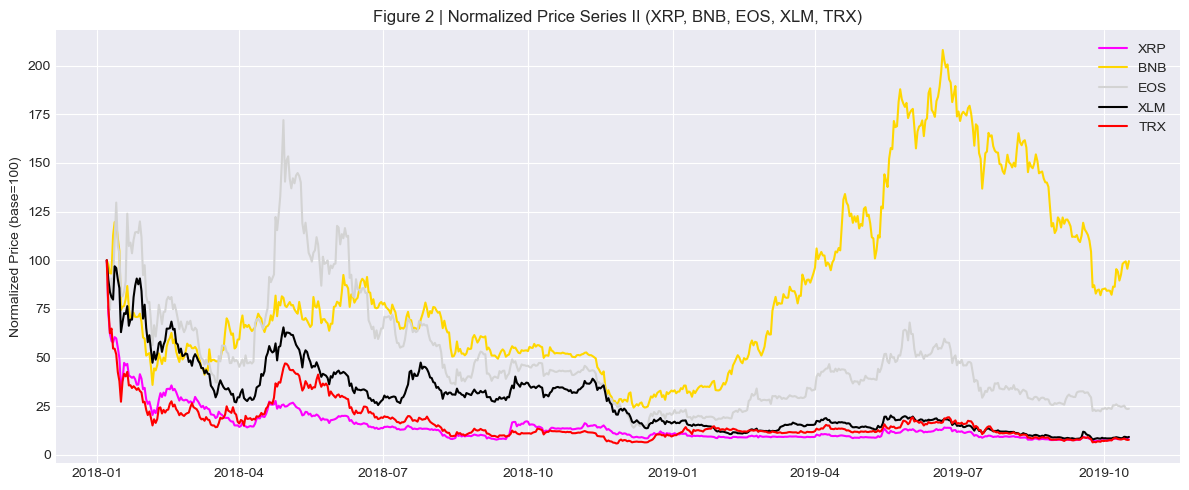

In [100]:
# --- Figure 1: BTC, ETH, USDT, BCH, LTC ---
assets_1  = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] / df_prices.loc['2018-01-07', assets_1]) * 100
colors_1  = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col], label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

# --- Figure 2: XRP, BNB, EOS, XLM, TRX ---
assets_2  = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] / df_prices.loc['2018-01-07', assets_2]) * 100
colors_2  = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col], label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Sel 5 — Visualisasi Minimum Spanning Tree (Figure 3 & 4)

Mereplikasi Figure 3 yang menunjukkan struktur jaringan aset kripto selama periode gelembung spekulatif (Sep 2017 – Jan 2018) dan periode stabil (Jun 2019 – Okt 2019).

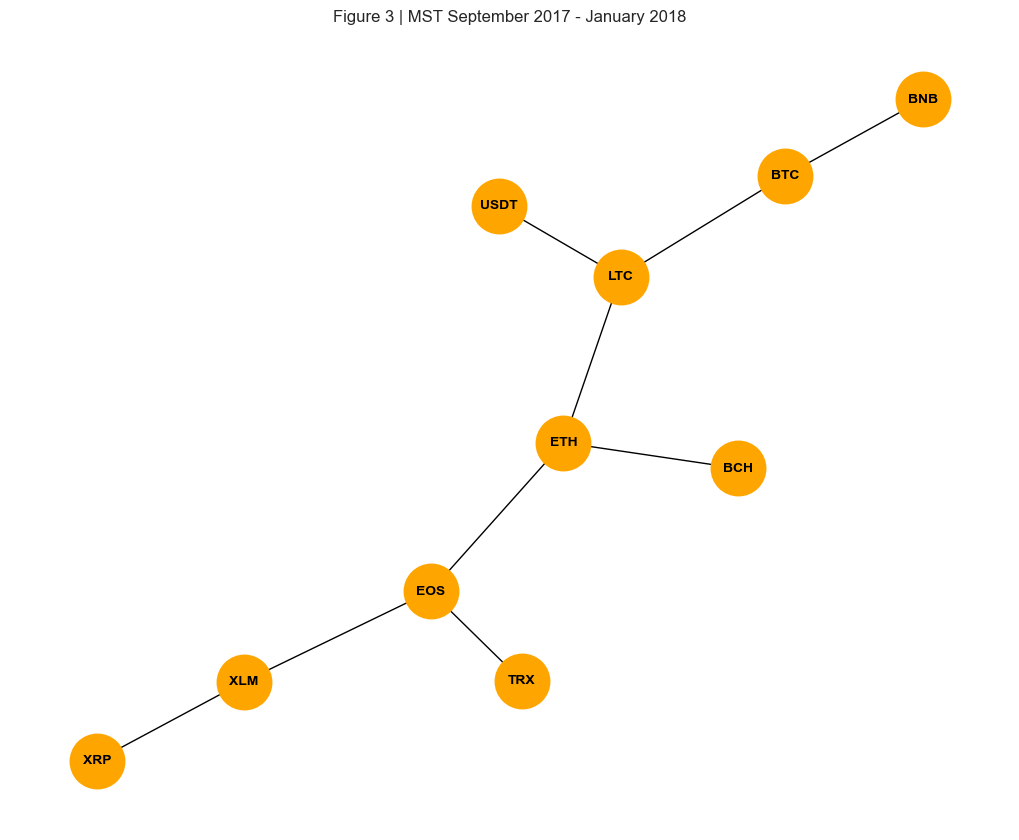

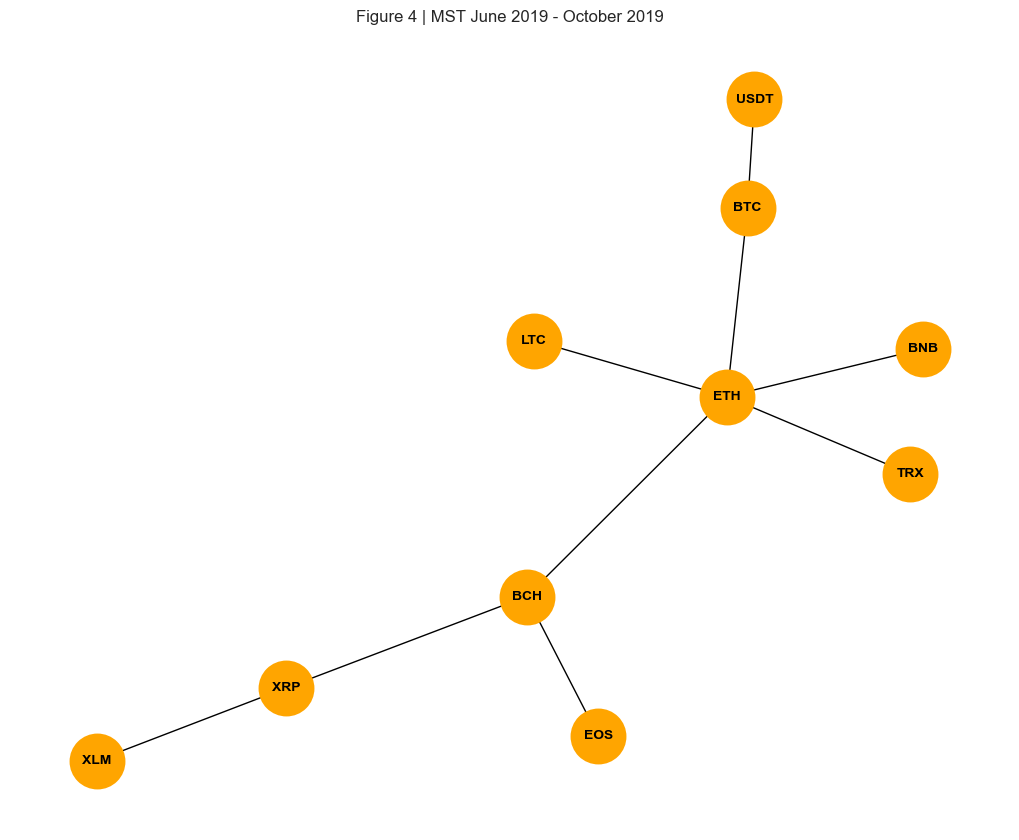

In [101]:
# --- Figure 3 | MST September 2017 - January 2018 (Speculative Bubble) ---
df_bubble  = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.tight_layout()
plt.show()

# --- Figure 4 | MST June 2019 - October 2019 ---
df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.tight_layout()
plt.show()

---
## Sel 6 — Fungsi Pembantu (Helper Functions)

Mengimplementasikan:
- **RMT Filter** — penyaringan noise matriks korelasi via Random Matrix Theory
- **MST Builder** — konstruksi matriks jarak untuk MST
- **Eigenvector Centrality** — ukuran sentralitas tiap aset dalam jaringan
- **Metrik Risiko** — VaR, Rachev Ratio, Max Drawdown
- **Graph Diversification** — pemilihan aset via Maximum Independent Set (MIS)

In [102]:
def apply_rmt_filter(returns_data):
    """Filter noise dari matriks korelasi menggunakan Random Matrix Theory (Marcenko-Pastur)."""
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
    T, N = data.shape
    Q    = T / N
    C    = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus      = 1 + (1 / Q) + 2 * np.sqrt(1 / Q)   # Marcenko-Pastur upper bound
    significant_mask = eigenvalues > lambda_plus
    Lambda_filtered  = np.diag(np.where(significant_mask, eigenvalues, 0))
    C_filtered       = eigenvectors @ Lambda_filtered @ eigenvectors.T
    return C_filtered


def build_mst(correlation_matrix):
    """Bangun matriks jarak dari matriks korelasi untuk MST."""
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    np.fill_diagonal(distance_matrix, 0)
    return distance_matrix


def compute_eigenvector_centrality(distance_matrix):
    """Hitung sentralitas eigenvector dari matriks jarak."""
    adjacency = 1 / (distance_matrix + 1e-8)
    np.fill_diagonal(adjacency, 0)
    eigenvalues, eigenvectors = eigh(adjacency)
    principal_eigenvector     = np.abs(eigenvectors[:, -1])
    centrality                = principal_eigenvector / principal_eigenvector.sum()
    return centrality


def calculate_var(returns, confidence=0.95):
    """Value at Risk pada confidence level tertentu."""
    return np.percentile(returns, (1 - confidence) * 100)


def calculate_rachev_ratio(returns, alpha=0.10):
    """Rachev Ratio = CVaR_upper(alpha) / CVaR_lower(alpha)."""
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    cvar_upper      = returns[returns >= threshold_upper].mean()
    cvar_lower      = abs(returns[returns <= threshold_lower].mean())
    return cvar_upper / cvar_lower if cvar_lower > 0 else 0


def calculate_max_drawdown(cumulative_returns):
    """Maksimum drawdown dari seri cumulative returns."""
    running_max = np.maximum.accumulate(cumulative_returns)
    drawdown    = (cumulative_returns - running_max) / running_max
    return drawdown.min()


def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """Cari aset independen menggunakan Maximum Independent Set (MIS) dari graf korelasi."""
    corr_mat = returns_window.corr()
    G        = nx.Graph()
    assets   = list(returns_window.mean().sort_values(ascending=False).index)
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for a2 in assets[i + 1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """MIS dengan korelasi yang sudah difilter RMT (noise-reduced)."""
    assets = returns_window.columns.tolist()
    corr_f = apply_rmt_filter(returns_window)   # numpy array
    G      = nx.Graph()
    G.add_nodes_from(assets)
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j and abs(corr_f[i, j]) > corr_threshold:
                G.add_edge(a1, a2)
    return list(nx.approximation.maximum_independent_set(G))


print("Helper functions defined successfully!")

Helper functions defined successfully!


---
## Sel New — Analisis Dinamika MST (Figure 5)

Analisis *rolling window* untuk menghitung ambang batas MST (*max link distance*) dan koefisien *residuality* sepanjang waktu.

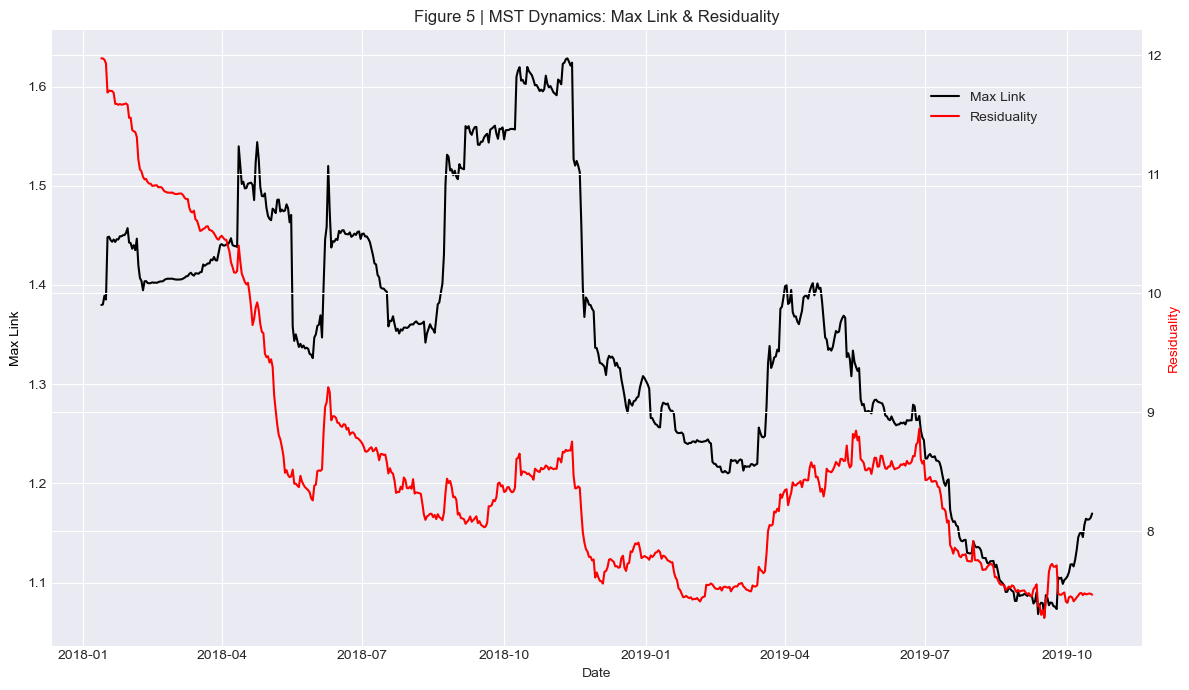

In [103]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates         = returns_df.index[window:]
    max_links     = []
    residualities = []

    for i in range(window, len(returns_df)):
        window_data  = returns_df.iloc[i - window:i]
        corr_f       = apply_rmt_filter(window_data)
        mst_weights  = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(np.sum(mst_weights) / (returns_df.shape[1] - 1))

    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )


mst_dyn = calculate_rolling_mst_metrics(df_returns)

# Visualisasi dual axis
fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'], color='black', label='Max Link')
ax1.set_xlabel('Date')
ax1.set_ylabel('Max Link', color='black')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'], color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title('Figure 5 | MST Dynamics: Max Link & Residuality')
plt.tight_layout()
plt.savefig('figure_5_mst_dynamics.png', dpi=150)
plt.show()

---
## Sel 7 — Implementasi Strategi Portofolio

Setiap strategi diimplementasikan sebagai kelas yang mewarisi `PortfolioStrategy`.

In [104]:
class PortfolioStrategy:
    def __init__(self, name):
        self.name            = name
        self.weights_history = []
        self.returns_history = []

    def get_weights(self, returns_data):
        raise NotImplementedError


# ── 1. Equally Weighted ────────────────────────────────────────────────────────
class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n


# ── 2. Classical Markowitz ─────────────────────────────────────────────────────
class ClassicalMarkowitz(PortfolioStrategy):
    """Optimasi Mean-Variance tradisional (minimasi varians portofolio)."""
    def get_weights(self, returns_data):
        n_assets    = returns_data.shape[1]
        mu          = returns_data.mean().values
        S           = returns_data.cov().values
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


# ── 3. Glasso Markowitz ────────────────────────────────────────────────────────
class GlassoMarkowitz(PortfolioStrategy):
    """Markowitz dengan matriks presisi yang diestimasi via Graphical Lasso."""
    def get_weights(self, returns_data):
        n_assets    = returns_data.shape[1]
        mu          = returns_data.mean().values
        try:
            glasso  = GraphicalLassoCV()
            glasso.fit(returns_data.values)
            S       = glasso.covariance_
        except Exception:
            S       = returns_data.cov().values
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


# ── 4. Network Markowitz ───────────────────────────────────────────────────────
class NetworkMarkowitz(PortfolioStrategy):
    """Network Markowitz: RMT + MST + penalti sentralitas eigenvector."""
    def __init__(self, name="Network Markowitz", gamma=0):
        super().__init__(name)
        self.gamma = gamma

    def get_weights(self, returns_data):
        n_assets    = returns_data.shape[1]
        mu          = returns_data.mean().values
        sig         = returns_data.std().values
        Cf          = apply_rmt_filter(returns_data)
        dist        = build_mst(Cf)
        cent        = compute_eigenvector_centrality(dist)
        Sf          = np.outer(sig, sig) * Cf
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(n_assets) / n_assets,
                       method='SLSQP', bounds=[(0, 1)] * n_assets,
                       constraints=constraints)
        return res.x if res.success else np.ones(n_assets) / n_assets


# ── 5. Graph Diversification ───────────────────────────────────────────────────
class GraphDiversification(PortfolioStrategy):
    """Strategi diversifikasi berbasis graf menggunakan Maximum Independent Set."""
    def __init__(self, name='Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


# ── 6. RMT Graph Diversification ──────────────────────────────────────────────
class RMTGraphDiversification(PortfolioStrategy):
    """Graph Diversification dengan korelasi difilter RMT terlebih dahulu."""
    def __init__(self, name='RMT Graph Diversification', corr_threshold=0.4):
        super().__init__(name)
        self.corr_threshold = corr_threshold

    def get_weights(self, r):
        n      = r.shape[1]
        assets = r.columns.tolist()
        sel    = get_assets_graph_diversify_rmt(r, self.corr_threshold)
        w      = np.zeros(n)
        if sel:
            for a in sel:
                w[assets.index(a)] = 1.0 / len(sel)
        else:
            w = np.ones(n) / n
        return w


print("Portfolio strategy classes defined successfully!")

Portfolio strategy classes defined successfully!


---
## Sel 8 — Framework Backtesting

Sistem pengujian menggunakan *rolling window* dengan biaya transaksi tetap **0.1%** (10 basis points).

In [105]:
def backtest_strategy(strategy, df_returns, window_size=120, rebalance_freq=7, transaction_cost=0.001):
    """Backtesting rolling window untuk strategi portofolio."""
    portfolio_returns = []
    dates             = []

    for i in range(window_size, len(df_returns), rebalance_freq):
        train    = df_returns.iloc[i - window_size:i]
        w        = strategy.get_weights(train)
        test_end = min(i + rebalance_freq, len(df_returns))
        test_data = df_returns.iloc[i:test_end]

        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates, 'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()

    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }

print("Backtest function defined successfully!")

Backtest function defined successfully!


---
## Sel 9 — Eksekusi Backtesting

Menjalankan simulasi backtest untuk semua varian strategi, termasuk berbagai nilai penalti γ untuk Network Markowitz.

In [106]:
# --- Inisialisasi semua strategi ---
gamma_values = [0.005, 0.025, 0.05, 0.15, 0.7, 1.0]

strategies = [
    EquallyWeighted("EW"),
    ClassicalMarkowitz("CM"),
    GlassoMarkowitz("GM"),
    NetworkMarkowitz("NW (gamma=0)", gamma=0),
] + [
    NetworkMarkowitz(f"NW (gamma={g})", gamma=g) for g in gamma_values
] + [
    GraphDiversification('Graph Divers. (theta=0.4)', corr_threshold=0.4),
    GraphDiversification('Graph Divers. (theta=0.5)', corr_threshold=0.5),
    RMTGraphDiversification('RMT GD (theta=0.4)',     corr_threshold=0.4),
]

# --- Eksekusi backtest ---
results = {}
for strat in strategies:
    print(f"Running: {strat.name} ...", end=' ')
    results[strat.name] = backtest_strategy(strat, df_returns)
    print("Done")

print("\nAll backtests completed!")

Running: EW ... Done
Running: CM ... Done
Running: GM ... Done
Running: NW (gamma=0) ... Done
Running: NW (gamma=0.005) ... Done
Running: NW (gamma=0.025) ... Done
Running: NW (gamma=0.05) ... Done
Running: NW (gamma=0.15) ... Done
Running: NW (gamma=0.7) ... Done
Running: NW (gamma=1.0) ... Done
Running: Graph Divers. (theta=0.4) ... Done
Running: Graph Divers. (theta=0.5) ... Done
Running: RMT GD (theta=0.4) ... Done

All backtests completed!


---
## Sel 10 — Analisis Performa Periodik (TABLE 2)

Tabel perbandingan performa kumulatif yang disampel setiap 4 bulan (Januari, Mei, September).

In [107]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat_name, res in results.items():
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 2 | Cumulative Profits and Losses (%)")
print(table2.to_string())

TABLE 2 | Cumulative Profits and Losses (%)
                           Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                                 
EW                         -35.53  -58.96  -77.02  -89.67  -77.88  -88.82
CM                         -34.32  -57.88  -59.66  -68.22  -55.67  -62.16
GM                         -33.86  -60.11  -61.90  -73.12  -62.49  -67.53
NW (gamma=0)               -41.59  -62.30  -63.81  -71.79  -61.83  -68.05
NW (gamma=0.005)           -41.62  -61.76  -64.22  -71.33  -62.41  -68.75
NW (gamma=0.025)           -44.13  -64.87  -66.29  -66.72  -57.08  -66.33
NW (gamma=0.05)            -44.80  -63.44  -64.60  -65.06  -55.14  -61.98
NW (gamma=0.15)            -44.65  -56.79  -58.18  -58.72  -46.94  -54.22
NW (gamma=0.7)             -40.13  -52.75  -54.21  -54.80  -41.90  -48.76
NW (gamma=1.0)             -39.09  -51.94  -53.57  -54.17  -41.10  -48.05
Graph Divers. (theta=0.4)  -38.42  -62.78  -69.03  -76.26  -55.09  -

---
## Sel 11 — Visualisasi Performa Kumulatif (Figure 6)

Evolusi nilai portofolio dengan asumsi investasi awal **100 USD**.

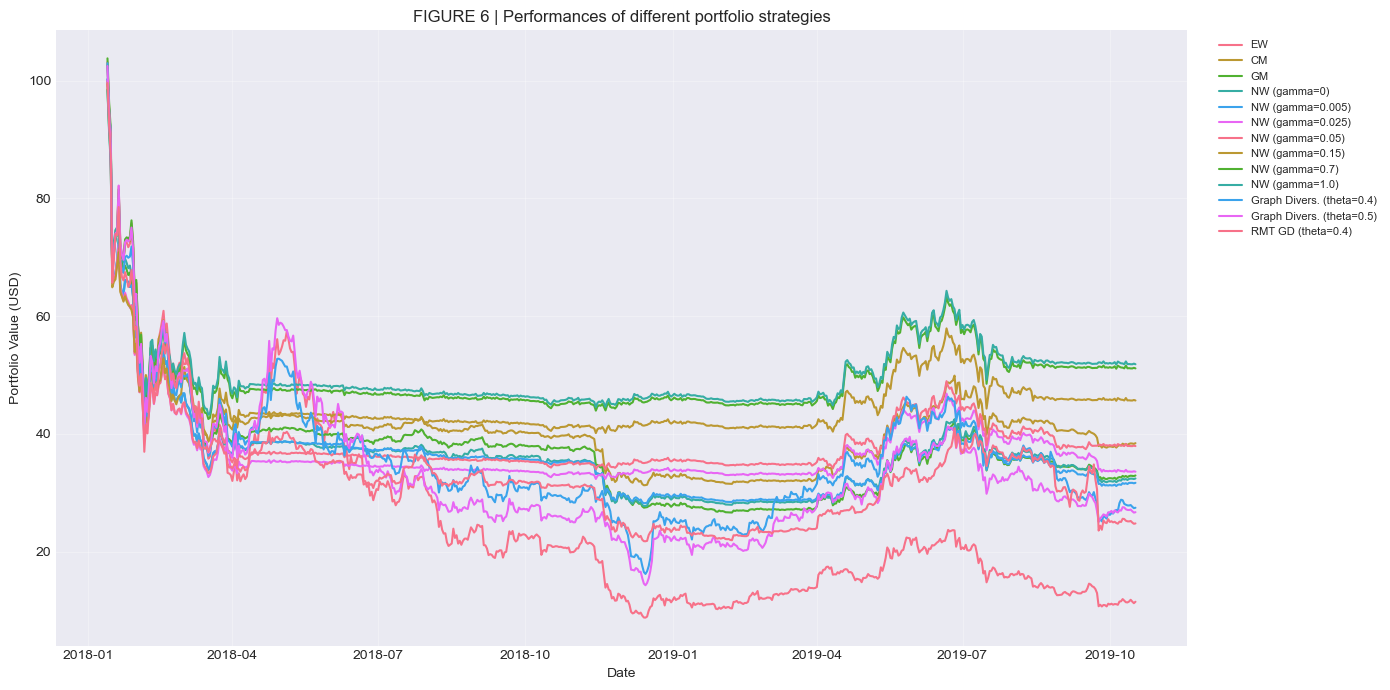

In [108]:
plt.figure(figsize=(14, 7))
for name, res in results.items():
    plt.plot(res['results_df']['date'],
             res['cumulative_returns'] * 100,
             label=name)

plt.title('FIGURE 6 | Performances of different portfolio strategies')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (USD)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sel 12 — Analisis Risiko Periodik (TABLE 3 — VaR)

Value at Risk (VaR) dengan tingkat kepercayaan **95%** untuk jendela 4 bulan. Nilai disajikan dalam bentuk absolut dikalikan faktor skala 100.

In [109]:
def get_periodic_returns(res_df, end_date, window_days=120):
    """Ambil return pada jendela 4-bulan sebelum end_date."""
    df    = res_df.set_index('date')
    end   = pd.Timestamp(end_date)
    start = end - pd.Timedelta(days=window_days)
    mask  = (df.index >= start) & (df.index <= end)
    return df.loc[mask, 'return'].values


table3_rows = []
for strat_name, res in results.items():
    row = {'Strategy': strat_name}
    for td in target_dates:
        seg = get_periodic_returns(res['results_df'], td)
        if len(seg) > 0:
            v = abs(calculate_var(seg, 0.95)) * 100
        else:
            v = np.nan
        row[td] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
table3.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 3 | Value at Risk (95%, scaled x100)")
print(table3.to_string())

TABLE 3 | Value at Risk (95%, scaled x100)
                            Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                                  
EW                         13.7904  9.5022  6.5585  9.5350  3.6718  8.2776
CM                         12.8261  5.7940  1.0018  1.7267  1.6995  3.8440
GM                         13.4648  5.9247  1.1860  2.4594  1.8105  4.3028
NW (gamma=0)               12.4709  5.5937  1.1532  1.8485  1.5132  4.0287
NW (gamma=0.005)           12.4241  5.5937  0.8311  1.6938  1.4809  3.4699
NW (gamma=0.025)           12.4356  5.8894  0.7126  0.9577  1.2485  3.1988
NW (gamma=0.05)            12.1764  5.5937  0.7126  0.9577  1.2485  3.0595
NW (gamma=0.15)            11.6335  5.6038  0.7126  0.9577  1.2792  3.1988
NW (gamma=0.7)             10.4548  5.6038  0.7126  0.9577  1.2792  3.0595
NW (gamma=1.0)             10.3486  5.6038  0.7126  0.9577  1.2792  3.0595
Graph Divers. (theta=0.4)  13.0552  9.0951  3.6555  5.884

---
## Sel 13 — Analisis Risk-Adjusted Return (TABLE 4 — Sharpe Ratio)

Sharpe ratio untuk jendela 4 bulan: `SR = Mean Return / Std Return`.

In [110]:
table4_rows = []
for strat_name, res in results.items():
    row = {'Strategy': strat_name}
    for td in target_dates:
        seg = get_periodic_returns(res['results_df'], td)
        if len(seg) > 1 and np.std(seg) > 0:
            sr = np.mean(seg) / np.std(seg)
        else:
            sr = np.nan
        row[td] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
table4.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 4 | Sharpe Ratio (4-month window)")
print(table4.to_string())

TABLE 4 | Sharpe Ratio (4-month window)
                           Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                                 
EW                        -0.2532 -0.0387 -0.0992 -0.1245  0.1955 -0.1294
CM                        -0.2508 -0.0880 -0.0623 -0.1497  0.1886 -0.0605
GM                        -0.2355 -0.0938 -0.0583 -0.1873  0.1743 -0.0531
NW (gamma=0)              -0.3442 -0.0942 -0.0572 -0.1535  0.1833 -0.0708
NW (gamma=0.005)          -0.3452 -0.0905 -0.1248 -0.1474  0.1675 -0.0745
NW (gamma=0.025)          -0.3860 -0.0957 -0.0768 -0.0145  0.1564 -0.1043
NW (gamma=0.05)           -0.4039 -0.0864 -0.0622 -0.0145  0.1549 -0.0691
NW (gamma=0.15)           -0.4061 -0.0403 -0.0619 -0.0145  0.1556 -0.0606
NW (gamma=0.7)            -0.3945 -0.0426 -0.0608 -0.0145  0.1556 -0.0516
NW (gamma=1.0)            -0.3849 -0.0426 -0.0692 -0.0145  0.1556 -0.0516
Graph Divers. (theta=0.4) -0.3018 -0.0549 -0.0434 -0.0434  0.2075 -0.140

---
## Sel 14 — Analisis Tail-Risk (TABLE 5 — Rachev Ratio)

Rachev Ratio memberikan wawasan tentang asimetri distribusi imbal hasil pada ekor distribusi (*tails*), yang umum di pasar kripto.

`RR = CVaR_upper(10%) / CVaR_lower(10%)`

In [111]:
table5_rows = []
for strat_name, res in results.items():
    row = {'Strategy': strat_name}
    for td in target_dates:
        seg = get_periodic_returns(res['results_df'], td)
        if len(seg) > 0:
            rr = calculate_rachev_ratio(seg, alpha=0.10)
        else:
            rr = np.nan
        row[td] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
table5.columns = ['Jan-18', 'May-18', 'Sep-18', 'Jan-19', 'May-19', 'Sep-19']

print("TABLE 5 | Rachev Ratio (4-month window, alpha=10%)")
print(table5.to_string())

TABLE 5 | Rachev Ratio (4-month window, alpha=10%)
                           Jan-18  May-18  Sep-18  Jan-19  May-19  Sep-19
Strategy                                                                 
EW                         0.3926  0.8936  0.8062  0.7200  1.7375  0.5381
CM                         0.3969  0.7673  0.7865  0.6506  1.9847  0.7510
GM                         0.4126  0.7528  0.7760  0.5600  1.6963  0.7353
NW (gamma=0)               0.2494  0.7707  0.7824  0.6389  2.0798  0.7820
NW (gamma=0.005)           0.2478  0.7725  0.6953  0.6421  2.0058  0.7798
NW (gamma=0.025)           0.2332  0.8103  0.7954  1.0171  2.1909  0.7588
NW (gamma=0.05)            0.1836  0.8367  0.8551  1.0171  2.1596  0.8317
NW (gamma=0.15)            0.1822  1.0056  0.8492  1.0171  2.1511  0.8379
NW (gamma=0.7)             0.2880  1.0185  0.8525  1.0171  2.1511  0.8614
NW (gamma=1.0)             0.3488  1.0185  0.8170  1.0171  2.1511  0.8614
Graph Divers. (theta=0.4)  0.3393  0.9174  1.0656  1.0366  2.